# Telco Customer Churn Analysis — Update 2
**Business Value Through Integrative Analytics | CMU Tepper | 2026**

Team: Ethan Kwon, Jihun Jeong, Henry Kim, Kerri Wang

---


## Notebook Structure
1. Setup & Data Preparation (replicates Update 1 pipeline)
2. Update 1 Fixes (Revenue at Risk bug, satisfaction_score in profile)
3. Signal Leakage Audit & Feature Taxonomy
4. Hypothesis Review from Update 1
5. Predictive Models (Logistic, Decision Tree, Random Forest, XGBoost)
6. Model Evaluation (ROC, AUC, Confusion Matrix, Lift)
7. Intervention Value Framework
8. Heuristic Strategies (5 strategies)
9. Cluster-level Analysis & Uncertainty Estimation
10. Temporal Validation
11. Managerial Summary

## Update 2 Overview

In this update, we move from descriptive segmentation to predictive modeling and simple prescription design for customer retention. Building on Update 1, we carry forward the cluster structure as a potential feature and managerial segmentation tool, while carefully auditing for signal leakage before training churn models. Our goal is not only to predict which customers are likely to churn, but also to translate those predictions into expected intervention value under realistic budget and contact constraints.

We evaluate several classification models, compare performance with and without cluster membership, and then use predicted churn probabilities together with CLTV to estimate revenue at risk and intervention value. This allows us to compare simple targeting heuristics and identify which strategies are most aligned with Horizon Telecom’s retention objective.

In [221]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, accuracy_score
)
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.base import clone

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False

In [222]:
file_path = 'Telco_Customer_Churn_Full_33.xlsx'
df_raw = pd.read_excel(file_path)

df = df_raw.copy()
print('Shape:', df.shape)
display(df.head())
print('\nColumns:')
print(df.columns.tolist())

Shape: (7043, 54)


,Customer ID,Count,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,...,Satisfaction Score,Customer Status,Churn Label,Churn Value,Churn Score,CLTV,Churn Category,Churn Reason,ID,Population
0,8779-QRDMV,1,Male,78,No,Yes,No,No,0,United States,...,3,Churned,Yes,1,91,5433,Competitor,Competitor offered more data,21,68701
1,7495-OOKFY,1,Female,74,No,Yes,Yes,Yes,1,United States,...,3,Churned,Yes,1,69,5302,Competitor,Competitor made better offer,54,55668
2,1658-BYGOY,1,Male,71,No,Yes,No,Yes,3,United States,...,2,Churned,Yes,1,81,3179,Competitor,Competitor made better offer,56,47534
3,4598-XLKNJ,1,Female,78,No,Yes,Yes,Yes,1,United States,...,2,Churned,Yes,1,88,5337,Dissatisfaction,Limited range of services,100,27778
4,4846-WHAFZ,1,Female,80,No,Yes,Yes,Yes,1,United States,...,2,Churned,Yes,1,67,2793,Price,Extra data charges,114,26265



Columns:
['Customer ID', 'Count', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Quarter', 'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Satisfaction Score', 'Customer Status', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Category', 'Churn Reason', 'ID', 'Population']


In [223]:
rename_map = {
    'Customer ID': 'customer_id',
    'Gender': 'gender',
    'Age': 'age',
    'Married': 'married',
    'Number of Dependents': 'num_dependents',
    'City': 'city',
    'Zip Code': 'zip_code',
    'Latitude': 'latitude',
    'Longitude': 'longitude',
    'Population': 'population',
    'Quarter': 'quarter',
    'Referred a Friend': 'referred_a_friend',
    'Number of Referrals': 'num_referrals',
    'Tenure in Months': 'tenure_months',
    'Offer': 'offer',
    'Phone Service': 'phone_service',
    'Avg Monthly Long Distance Charges': 'avg_monthly_long_distance_charges',
    'Multiple Lines': 'multiple_lines',
    'Internet Service': 'internet_service',
    'Internet Type': 'internet_type',
    'Avg Monthly GB Download': 'avg_monthly_gb_download',
    'Online Security': 'online_security',
    'Online Backup': 'online_backup',
    'Device Protection Plan': 'device_protection_plan',
    'Premium Tech Support': 'premium_tech_support',
    'Streaming TV': 'streaming_tv',
    'Streaming Movies': 'streaming_movies',
    'Streaming Music': 'streaming_music',
    'Unlimited Data': 'unlimited_data',
    'Contract': 'contract',
    'Paperless Billing': 'paperless_billing',
    'Payment Method': 'payment_method',
    'Monthly Charge': 'monthly_charge',
    'Total Charges': 'total_charges',
    'Total Refunds': 'total_refunds',
    'Total Extra Data Charges': 'total_extra_data_charges',
    'Total Long Distance Charges': 'total_long_distance_charges',
    'Total Revenue': 'total_revenue',
    'Customer Status': 'customer_status',
    'Churn Category': 'churn_category',
    'Churn Reason': 'churn_reason',
    'Churn Value': 'churn_value',
    'Churn Score': 'churn_score',
    'CLTV': 'cltv',
    'Satisfaction Score': 'satisfaction_score'
}

df = df.rename(columns={c: rename_map.get(c, c) for c in df.columns})
print(df.columns.tolist())

['customer_id', 'Count', 'gender', 'age', 'Under 30', 'Senior Citizen', 'married', 'Dependents', 'num_dependents', 'Country', 'State', 'city', 'zip_code', 'Lat Long', 'latitude', 'longitude', 'quarter', 'referred_a_friend', 'num_referrals', 'tenure_months', 'offer', 'phone_service', 'avg_monthly_long_distance_charges', 'multiple_lines', 'internet_service', 'internet_type', 'avg_monthly_gb_download', 'online_security', 'online_backup', 'device_protection_plan', 'premium_tech_support', 'streaming_tv', 'streaming_movies', 'streaming_music', 'unlimited_data', 'contract', 'paperless_billing', 'payment_method', 'monthly_charge', 'total_charges', 'total_refunds', 'total_extra_data_charges', 'total_long_distance_charges', 'total_revenue', 'satisfaction_score', 'customer_status', 'Churn Label', 'churn_value', 'churn_score', 'cltv', 'churn_category', 'churn_reason', 'ID', 'population']


In [224]:
numeric_candidates = [
    'age', 'num_dependents', 'num_referrals', 'tenure_months',
    'avg_monthly_long_distance_charges', 'avg_monthly_gb_download',
    'monthly_charge', 'total_charges', 'total_refunds',
    'total_extra_data_charges', 'total_long_distance_charges',
    'total_revenue', 'churn_value', 'churn_score', 'cltv',
    'satisfaction_score', 'population', 'latitude', 'longitude'
]

for col in numeric_candidates:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

if 'customer_id' not in df.columns:
    df['customer_id'] = np.arange(len(df))

if 'churn_value' in df.columns:
    df['target'] = df['churn_value'].astype(int)
elif 'customer_status' in df.columns:
    df['target'] = (df['customer_status'].astype(str).str.lower() == 'churned').astype(int)
else:
    raise ValueError('Cannot identify churn target column.')

print(df['target'].value_counts(dropna=False))
print('Overall churn rate:', df['target'].mean())

target
0    5174
1    1869
Name: count, dtype: int64
Overall churn rate: 0.2653698707936959


In [225]:
service_cols = [
    'online_security', 'online_backup', 'device_protection_plan',
    'premium_tech_support', 'streaming_tv', 'streaming_movies',
    'streaming_music', 'unlimited_data'
]

for col in service_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.lower()
        df[col] = df[col].replace({
            'yes': 1, 'no': 0,
            'no internet service': 0,
            'no phone service': 0
        })
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

In [226]:
binary_map_cols = [
    'married', 'referred_a_friend', 'phone_service',
    'multiple_lines', 'internet_service', 'paperless_billing'
]
for col in binary_map_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.lower().map({
            'yes': 1, 'no': 0
        })

In [227]:
existing_service_cols = [c for c in service_cols if c in df.columns]
df['service_bundle_count'] = df[existing_service_cols].sum(axis=1)

def make_tenure_segment(x):
    if pd.isna(x):
        return np.nan
    if x <= 12:
        return 'New'
    elif x <= 36:
        return 'Developing'
    else:
        return 'Established'

df['tenure_segment'] = df['tenure_months'].apply(make_tenure_segment)

In [228]:
eng_cols = ['num_referrals', 'service_bundle_count', 'tenure_months']
eng_df = df[eng_cols].copy()
for c in eng_cols:
    eng_df[c] = eng_df[c].fillna(eng_df[c].median())
    std = eng_df[c].std()
    if std == 0 or pd.isna(std):
        eng_df[c + '_z'] = 0
    else:
        eng_df[c + '_z'] = (eng_df[c] - eng_df[c].mean()) / std

df['engagement_index'] = eng_df[[c + '_z' for c in eng_cols]].sum(axis=1)

In [229]:
leaky_features = [
    'churn_value', 'target', 'customer_status', 'churn_category', 'churn_reason'
]
risky_features = ['satisfaction_score', 'churn_score']

In [230]:
candidate_features = [
    'gender', 'age', 'married', 'num_dependents',
    'num_referrals', 'tenure_months', 'offer', 'phone_service',
    'avg_monthly_long_distance_charges', 'multiple_lines',
    'internet_service', 'internet_type', 'avg_monthly_gb_download',
    'online_security', 'online_backup', 'device_protection_plan',
    'premium_tech_support', 'streaming_tv', 'streaming_movies',
    'streaming_music', 'unlimited_data', 'contract', 'paperless_billing',
    'payment_method', 'monthly_charge', 'total_charges', 'total_refunds',
    'total_extra_data_charges', 'total_long_distance_charges', 'total_revenue',
    'cltv', 'satisfaction_score',
    'service_bundle_count', 'tenure_segment', 'engagement_index'
]
candidate_features = [c for c in candidate_features if c in df.columns]

print('Number of candidate features:', len(candidate_features))
print(candidate_features)


Number of candidate features: 35
['gender', 'age', 'married', 'num_dependents', 'num_referrals', 'tenure_months', 'offer', 'phone_service', 'avg_monthly_long_distance_charges', 'multiple_lines', 'internet_service', 'internet_type', 'avg_monthly_gb_download', 'online_security', 'online_backup', 'device_protection_plan', 'premium_tech_support', 'streaming_tv', 'streaming_movies', 'streaming_music', 'unlimited_data', 'contract', 'paperless_billing', 'payment_method', 'monthly_charge', 'total_charges', 'total_refunds', 'total_extra_data_charges', 'total_long_distance_charges', 'total_revenue', 'cltv', 'satisfaction_score', 'service_bundle_count', 'tenure_segment', 'engagement_index']


In [231]:
model_df = df[['customer_id', 'target'] + candidate_features].copy()

train_df, test_df = train_test_split(
    model_df,
    test_size=0.30,
    random_state=42,
    stratify=model_df['target']
)

print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)
print('Train churn rate:', train_df['target'].mean())
print('Test churn rate:', test_df['target'].mean())


Train shape: (4930, 37)
Test shape: (2113, 37)
Train churn rate: 0.2653144016227181
Test churn rate: 0.26549929010885


In [232]:
cluster_features = [
    'tenure_months', 'monthly_charge', 'cltv', 'satisfaction_score',
    'num_referrals', 'service_bundle_count', 'engagement_index'
]
cluster_features = [c for c in cluster_features if c in train_df.columns]

cluster_train = train_df[cluster_features].copy()
cluster_test = test_df[cluster_features].copy()

cluster_imputer = SimpleImputer(strategy='median')
cluster_scaler = StandardScaler()

X_cluster_train = cluster_imputer.fit_transform(cluster_train)
X_cluster_train = cluster_scaler.fit_transform(X_cluster_train)

X_cluster_test = cluster_imputer.transform(cluster_test)
X_cluster_test = cluster_scaler.transform(X_cluster_test)


In [233]:
k_results = []
for k in range(3, 9):
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_tmp = km_tmp.fit_predict(X_cluster_train)
    sil = silhouette_score(X_cluster_train, labels_tmp)
    k_results.append((k, sil, km_tmp.inertia_))

k_results_df = pd.DataFrame(k_results, columns=['k', 'silhouette', 'inertia'])
display(k_results_df)


,k,silhouette,inertia
0,3,0.243949,19522.727740
1,4,0.228321,16991.155209
2,5,0.226195,15161.537410
3,6,0.226457,13730.306763
4,7,0.224610,12667.251293
5,8,0.226486,11820.651182


In [234]:
k_final = 4
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=20)
train_df['cluster_raw'] = kmeans.fit_predict(X_cluster_train)


In [235]:
centroids = kmeans.cluster_centers_
dist_matrix = np.sqrt(((X_cluster_test[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2))
test_df['cluster_raw'] = dist_matrix.argmin(axis=1)

print(train_df['cluster_raw'].value_counts().sort_index())
print(test_df['cluster_raw'].value_counts().sort_index())

cluster_raw
0    1516
1    1185
2    1428
3     801
Name: count, dtype: int64
cluster_raw
0    644
1    509
2    608
3    352
Name: count, dtype: int64


In [236]:
cluster_profile_train = train_df.groupby('cluster_raw').agg(
    churn_rate=('target', 'mean'),
    avg_cltv=('cltv', 'mean'),
    avg_tenure=('tenure_months', 'mean'),
    avg_bundle=('service_bundle_count', 'mean'),
    avg_referrals=('num_referrals', 'mean')
).round(3)
display(cluster_profile_train)

,churn_rate,avg_cltv,avg_tenure,avg_bundle,avg_referrals
cluster_raw,,,,,
0,0.677,3789.056,13.125,2.924,0.466
1,0.161,5007.455,53.414,5.370,0.880
2,0.051,4307.373,24.638,0.625,1.232
3,0.022,4809.793,51.969,4.342,7.541


In [237]:
cluster_name_map = {
    0: 'Early_High_Risk',
    1: 'High_Value_Bundled',
    2: 'Stable_Low_Usage',
    3: 'Loyal_Advocates'
}

train_df['cluster_name'] = train_df['cluster_raw'].map(cluster_name_map)
test_df['cluster_name'] = test_df['cluster_raw'].map(cluster_name_map)

In [238]:
# version A: without cluster
base_features = [c for c in candidate_features if c not in leaky_features]

# version B: with cluster as NOMINAL feature (correct way)
features_with_cluster = base_features + ['cluster_name']

# sensitivity version without satisfaction_score
features_no_satisfaction = [
    c for c in base_features
    if c not in ['satisfaction_score', 'churn_score']
] + ['cluster_name']

leaky_audit_features_strong = list(set(
    base_features +
    [c for c in ['customer_status', 'churn_category', 'churn_reason'] if c in train_df.columns]
))

# fully leaky version for audit only
leaky_audit_features = list(set(
    base_features +
    [c for c in [
        'customer_status',
        'churn_category',
        'churn_reason',
        'churn_value',
        'target'
    ] if c in df.columns]
))
leaky_audit_features = [c for c in leaky_audit_features if c != 'target']

In [239]:
def get_feature_types(dataframe, feature_list):
    numeric_cols = []
    categorical_cols = []
    for col in feature_list:
        if col not in dataframe.columns:
            continue
        if pd.api.types.is_numeric_dtype(dataframe[col]):
            numeric_cols.append(col)
        else:
            categorical_cols.append(col)
    return numeric_cols, categorical_cols

In [240]:
def build_preprocessor(dataframe, feature_list):
    numeric_cols, categorical_cols = get_feature_types(dataframe, feature_list)

    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_cols),
            ('cat', 'passthrough', categorical_cols)
        ],
        remainder='drop'
    )

    return preprocessor, numeric_cols, categorical_cols

In [241]:
def one_hot_after_preprocess(X_df, categorical_cols):
    X_out = X_df.copy()
    if len(categorical_cols) > 0:
        X_out = pd.get_dummies(X_out, columns=categorical_cols, drop_first=True)
    return X_out

def prepare_X(train_sub, test_sub, feature_list):
    preprocessor, numeric_cols, categorical_cols = build_preprocessor(train_sub, feature_list)

    X_train_numcat = train_sub[feature_list].copy()
    X_test_numcat = test_sub[feature_list].copy()

    # impute + scale numeric; pass categorical through
    X_train_proc = preprocessor.fit_transform(X_train_numcat)
    X_test_proc = preprocessor.transform(X_test_numcat)

    out_cols = numeric_cols + categorical_cols
    X_train_proc = pd.DataFrame(X_train_proc, index=train_sub.index, columns=out_cols)
    X_test_proc = pd.DataFrame(X_test_proc, index=test_sub.index, columns=out_cols)

    X_train_final = one_hot_after_preprocess(X_train_proc, categorical_cols)
    X_test_final = one_hot_after_preprocess(X_test_proc, categorical_cols)

    X_train_final, X_test_final = X_train_final.align(X_test_final, join='left', axis=1, fill_value=0)

    X_train_final = X_train_final.apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)
    X_test_final = X_test_final.apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)

    return X_train_final, X_test_final

In [242]:
def top_decile_lift(y_true, y_score, top_pct=0.10):
    temp = pd.DataFrame({'y_true': y_true, 'y_score': y_score}).sort_values('y_score', ascending=False)
    n_top = max(1, int(len(temp) * top_pct))
    top_rate = temp.head(n_top)['y_true'].mean()
    overall_rate = temp['y_true'].mean()
    if overall_rate == 0:
        return np.nan
    return top_rate / overall_rate

In [243]:
def evaluate_classifier(model, X_train, y_train, X_test, y_test, threshold=0.5, model_name='Model'):
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    results = {
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'auc': roc_auc_score(y_test, y_prob),
        'lift_top_10pct': top_decile_lift(y_test, y_prob, top_pct=0.10)
    }
    return results, y_prob, y_pred, model


In [244]:
X_train_clean, X_test_clean = prepare_X(train_df, test_df, features_with_cluster)
y_train = train_df['target']
y_test = test_df['target']

leaky_audit_features_strong = list(set(
    base_features +
    [c for c in ['customer_status', 'churn_category', 'churn_reason'] if c in train_df.columns]
))


In [245]:
logit_clean_audit = LogisticRegression(
    penalty='l2', C=1.0, solver='liblinear', random_state=42, max_iter=1000, class_weight='balanced'
)

clean_audit_results, clean_audit_prob, clean_audit_pred, _ = evaluate_classifier(
    clone(logit_clean_audit), X_train_clean, y_train, X_test_clean, y_test, model_name='Logit_Clean_WithCluster'
)

X_train_leaky_strong, X_test_leaky_strong = prepare_X(train_df, test_df, leaky_audit_features_strong)

res_leaky_strong, prob_leaky_strong, pred_leaky_strong, _ = evaluate_classifier(
    clone(logit_clean_audit),
    X_train_leaky_strong,
    y_train,
    X_test_leaky_strong,
    y_test,
    model_name='Logit_Leaky_Strong'
)

audit_rows = [clean_audit_results, res_leaky_strong]

audit_df = pd.DataFrame(audit_rows)
display(audit_df)


,model,accuracy,precision,recall,f1,auc,lift_top_10pct
0,Logit_Clean_WithCluster,0.946995,0.863857,0.950089,0.904924,0.990435,3.766488
1,Logit_Leaky_Strong,0.945575,0.862013,0.946524,0.902294,0.990714,3.766488


In [246]:
X_train_no_cluster, X_test_no_cluster = prepare_X(train_df, test_df, base_features)
X_train_with_cluster, X_test_with_cluster = X_train_clean.copy(), X_test_clean.copy()

compare_models = {
    'Logistic_NoCluster': LogisticRegression(
        penalty='l2', C=1.0, solver='liblinear', random_state=42, max_iter=1000, class_weight='balanced'
    ),
    'Logistic_WithCluster': LogisticRegression(
        penalty='l2', C=1.0, solver='liblinear', random_state=42, max_iter=1000, class_weight='balanced'
    )
}

comparison_rows = []
res1, prob1, pred1, m1 = evaluate_classifier(compare_models['Logistic_NoCluster'], X_train_no_cluster, y_train, X_test_no_cluster, y_test, model_name='Logistic_NoCluster')
comparison_rows.append(res1)
res2, prob2, pred2, m2 = evaluate_classifier(compare_models['Logistic_WithCluster'], X_train_with_cluster, y_train, X_test_with_cluster, y_test, model_name='Logistic_WithCluster')
comparison_rows.append(res2)

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)


,model,accuracy,precision,recall,f1,auc,lift_top_10pct
0,Logistic_NoCluster,0.945102,0.860616,0.946524,0.901528,0.990714,3.766488
1,Logistic_WithCluster,0.946995,0.863857,0.950089,0.904924,0.990435,3.766488


In [247]:
X_train_tree = X_train_with_cluster.copy()
X_test_tree = X_test_with_cluster.copy()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tree = DecisionTreeClassifier(random_state=42, class_weight='balanced')
param_grid_tree = {
    'max_depth': [3, 4, 5, 6, 8],
    'min_samples_leaf': [10, 20, 40, 60],
    'criterion': ['gini', 'entropy']
}

grid_tree = GridSearchCV(
    estimator=tree,
    param_grid=param_grid_tree,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1
)

grid_tree.fit(X_train_tree, y_train)
best_tree = grid_tree.best_estimator_
print('Best tree params:', grid_tree.best_params_)


Best tree params: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 60}


In [248]:
res_tree, prob_tree, pred_tree, fitted_tree = evaluate_classifier(
    best_tree, X_train_tree, y_train, X_test_tree, y_test, model_name='DecisionTree_CV'
)
display(pd.DataFrame([res_tree]))


,model,accuracy,precision,recall,f1,auc,lift_top_10pct
0,DecisionTree_CV,0.930904,0.81874,0.950089,0.879538,0.984269,3.766488


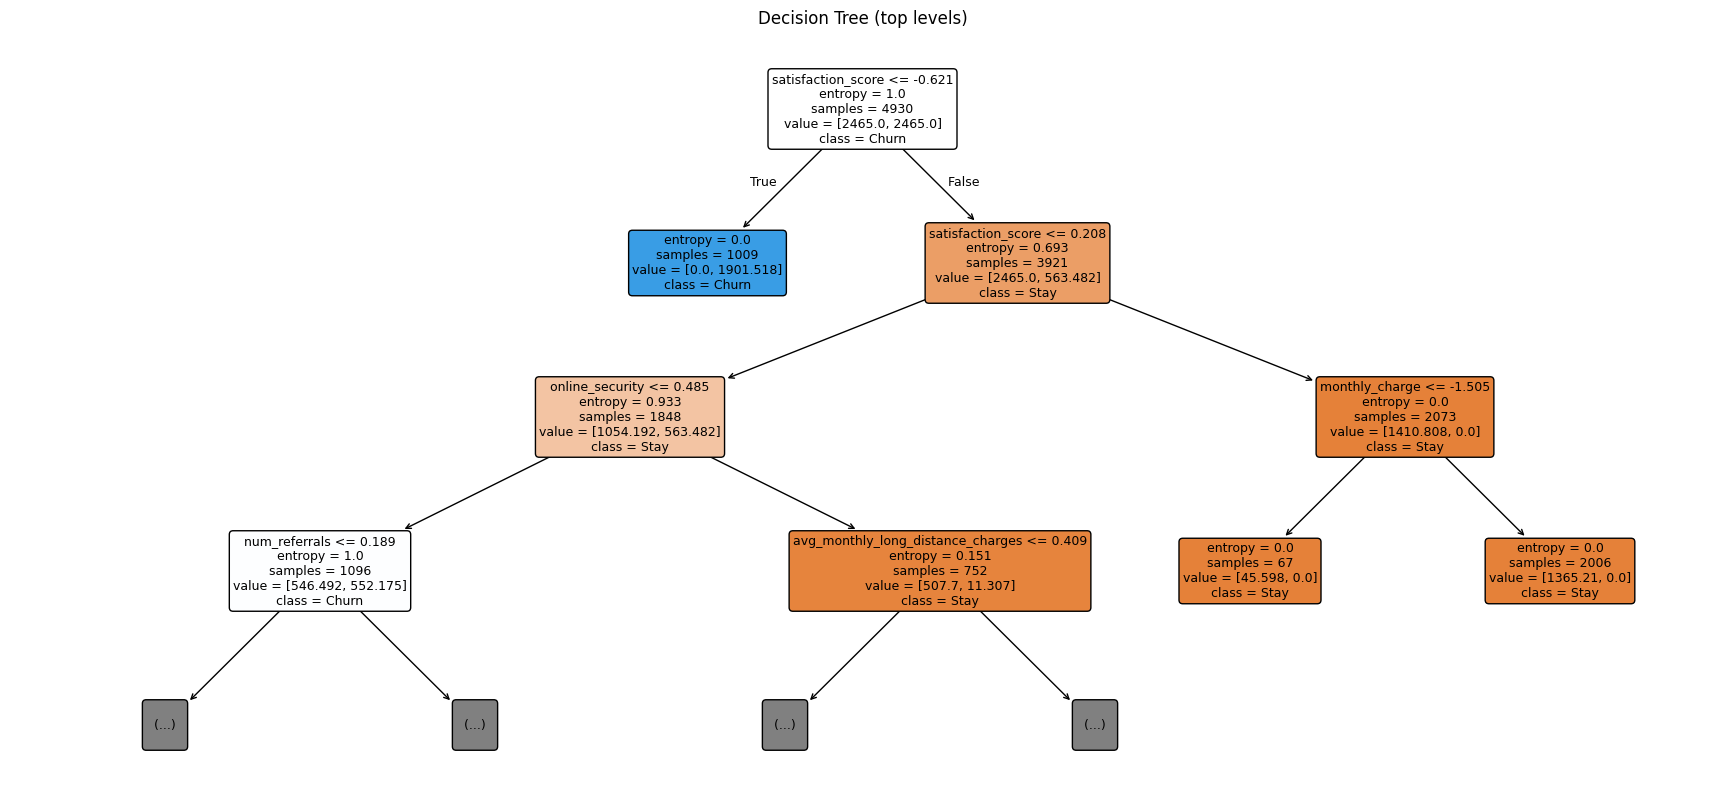

In [249]:
plt.figure(figsize=(22, 10))
plot_tree(
    fitted_tree,
    feature_names=X_train_tree.columns,
    class_names=['Stay', 'Churn'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)
plt.title('Decision Tree (top levels)')
plt.show()

In [250]:
print(export_text(fitted_tree, feature_names=list(X_train_tree.columns), max_depth=3))


|--- satisfaction_score <= -0.62
|   |--- class: 1
|--- satisfaction_score >  -0.62
|   |--- satisfaction_score <= 0.21
|   |   |--- online_security <= 0.49
|   |   |   |--- num_referrals <= 0.19
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- num_referrals >  0.19
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- online_security >  0.49
|   |   |   |--- avg_monthly_long_distance_charges <= 0.41
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- avg_monthly_long_distance_charges >  0.41
|   |   |   |   |--- truncated branch of depth 3
|   |--- satisfaction_score >  0.21
|   |   |--- monthly_charge <= -1.51
|   |   |   |--- class: 0
|   |   |--- monthly_charge >  -1.51
|   |   |   |--- class: 0



In [252]:
from sklearn.linear_model import LogisticRegressionCV

logit_cv_model = LogisticRegressionCV(
    Cs=[0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10],
    cv=5,
    penalty='l2',
    solver='liblinear',
    random_state=42,
    max_iter=1000,
    class_weight='balanced',
    scoring='roc_auc'
)

logit_cv_model.fit(X_train_with_cluster, y_train)

best_C = logit_cv_model.C_[0]
print('Chosen C:', best_C)

res_logit, prob_logit, pred_logit, fitted_logit = evaluate_classifier(
    LogisticRegression(
        penalty='l2',
        C=best_C,
        solver='liblinear',
        random_state=42,
        max_iter=1000,
        class_weight='balanced'
    ),
    X_train_with_cluster,
    y_train,
    X_test_with_cluster,
    y_test,
    model_name='Logistic_L2_CV'
)

display(pd.DataFrame([res_logit]))

Chosen C: 10.0


,model,accuracy,precision,recall,f1,auc,lift_top_10pct
0,Logistic_L2_CV,0.946522,0.863636,0.948307,0.903993,0.990659,3.766488


In [253]:
coef_df = pd.DataFrame({
    'feature': X_train_with_cluster.columns,
    'coef': fitted_logit.coef_[0],
    'abs_coef': np.abs(fitted_logit.coef_[0])
}).sort_values('abs_coef', ascending=False)
display(coef_df.head(15))


,feature,coef,abs_coef
26,satisfaction_score,-9.486684,9.486684
3,num_referrals,-1.699175,1.699175
37,contract_Two Year,-1.578483,1.578483
10,online_security,-1.458999,1.458999
28,engagement_index,-1.105936,1.105936
19,monthly_charge,0.862636,0.862636
1,married,0.859955,0.859955
44,cluster_name_Stable_Low_Usage,-0.827900,0.827900
35,internet_type_Fiber Optic,-0.761808,0.761808
32,offer_Offer D,-0.735395,0.735395


In [254]:
model_rows = [res_tree, res_logit]
all_probs = {
    'DecisionTree_CV': prob_tree,
    'Logistic_L2_CV': prob_logit
}
all_models = {
    'DecisionTree_CV': fitted_tree,
    'Logistic_L2_CV': fitted_logit
}

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    class_weight='balanced_subsample',
    n_jobs=-1
)
res_rf, prob_rf, pred_rf, fitted_rf = evaluate_classifier(
    rf, X_train_with_cluster, y_train, X_test_with_cluster, y_test, model_name='RandomForest'
)
model_rows.append(res_rf)
all_probs['RandomForest'] = prob_rf
all_models['RandomForest'] = fitted_rf

X_train_with_cluster = X_train_with_cluster.apply(pd.to_numeric, errors='coerce')
X_test_with_cluster = X_test_with_cluster.apply(pd.to_numeric, errors='coerce')

X_train_with_cluster = X_train_with_cluster.fillna(0).astype(float)
X_test_with_cluster = X_test_with_cluster.fillna(0).astype(float)

if XGB_AVAILABLE:
    xgb = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42
    )
    res_xgb, prob_xgb, pred_xgb, fitted_xgb = evaluate_classifier(
        xgb, X_train_with_cluster, y_train, X_test_with_cluster, y_test, model_name='XGBoost'
    )
    model_rows.append(res_xgb)
    all_probs['XGBoost'] = prob_xgb
    all_models['XGBoost'] = fitted_xgb

model_comparison_df = pd.DataFrame(model_rows).sort_values('auc', ascending=False)
display(model_comparison_df)


,model,accuracy,precision,recall,f1,auc,lift_top_10pct
3,XGBoost,0.960719,0.950943,0.898396,0.923923,0.991451,3.766488
1,Logistic_L2_CV,0.946522,0.863636,0.948307,0.903993,0.990659,3.766488
0,DecisionTree_CV,0.930904,0.818740,0.950089,0.879538,0.984269,3.766488
2,RandomForest,0.946048,0.883362,0.918004,0.900350,0.982635,3.766488


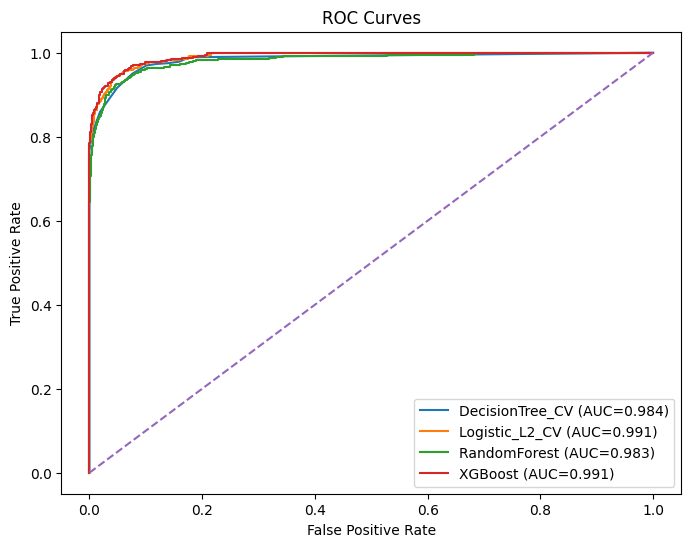

In [255]:
plt.figure(figsize=(8, 6))
for name, prob in all_probs.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

In [256]:
if XGB_AVAILABLE and 'XGBoost' in all_probs:
    final_model_name = 'XGBoost'
else:
    final_model_name = 'RandomForest'

final_prob = all_probs[final_model_name]
final_model = all_models[final_model_name]
print('Chosen final model:', final_model_name)

Chosen final model: XGBoost


In [257]:
test_results = test_df[['customer_id', 'target', 'cltv', 'cluster_name']].copy()
test_results['p_churn'] = final_prob
test_results['pred_label_05'] = (test_results['p_churn'] >= 0.5).astype(int)


In [258]:
true_positive_case = test_results[(test_results['target'] == 1) & (test_results['pred_label_05'] == 1)].sort_values('p_churn', ascending=False).head(1)
true_negative_case = test_results[(test_results['target'] == 0) & (test_results['pred_label_05'] == 0)].sort_values('p_churn', ascending=True).head(1)
false_negative_case = test_results[(test_results['target'] == 1) & (test_results['pred_label_05'] == 0)].sort_values('p_churn', ascending=False).head(1)

print('True Positive example')
display(true_positive_case)
print('True Negative example')
display(true_negative_case)
print('False Negative example')
display(false_negative_case)


True Positive example


,customer_id,target,cltv,cluster_name,p_churn,pred_label_05
1772,0895-DQHEW,1,4019,High_Value_Bundled,0.999884,1


True Negative example


,customer_id,target,cltv,cluster_name,p_churn,pred_label_05
5110,6752-APNJL,0,3449,Loyal_Advocates,0.000022,0


False Negative example


,customer_id,target,cltv,cluster_name,p_churn,pred_label_05
1450,2886-KEFUM,1,6144,High_Value_Bundled,0.486756,0


In [259]:
tier_params = {
    1: {'name': 'Email', 'cost': 5, 'eta': 0.10},
    2: {'name': 'Call', 'cost': 15, 'eta': 0.25},
    3: {'name': 'Discount', 'cost': 50, 'eta': 0.45}
}

test_results['revenue_at_risk'] = test_results['p_churn'] * test_df['cltv'].fillna(test_df['cltv'].median())

for j in [1, 2, 3]:
    test_results[f'v{j}'] = test_results['p_churn'] * tier_params[j]['eta'] * test_df['cltv'].fillna(test_df['cltv'].median()) - tier_params[j]['cost']


In [260]:
value_cols = ['v1', 'v2', 'v3']
test_results['best_value'] = test_results[value_cols].max(axis=1)
test_results['best_tier'] = test_results[value_cols].idxmax(axis=1).str.replace('v', '').astype(int)


In [261]:
display(test_results.head())

def positive_count(col):
    return (test_results[col] > 0).sum()

print('Positive-value customer counts by tier:')
for col in value_cols:
    print(col, positive_count(col))


,customer_id,target,cltv,cluster_name,p_churn,pred_label_05,revenue_at_risk,v1,v2,v3,best_value,best_tier
1976,6715-OFDBP,1,4944,Early_High_Risk,0.998720,1,4937.672516,488.767244,1219.418129,2171.952544,2171.952544,3
6891,8725-JEDFD,0,3241,Stable_Low_Usage,0.000333,0,1.079812,-4.892019,-14.730047,-49.514085,-4.892019,1
184,7409-KIUTL,1,5345,Early_High_Risk,0.909180,1,4859.569571,480.956973,1199.892393,2136.806259,2136.806259,3
777,0928-JMXNP,0,2914,Stable_Low_Usage,0.001361,0,3.964804,-4.603520,-14.008799,-48.215838,-4.603520,1
2599,3212-KXOCR,0,4158,Stable_Low_Usage,0.000306,0,1.273982,-4.872602,-14.681505,-49.426708,-4.872602,1


Positive-value customer counts by tier:
v1 881
v2 853
v3 785


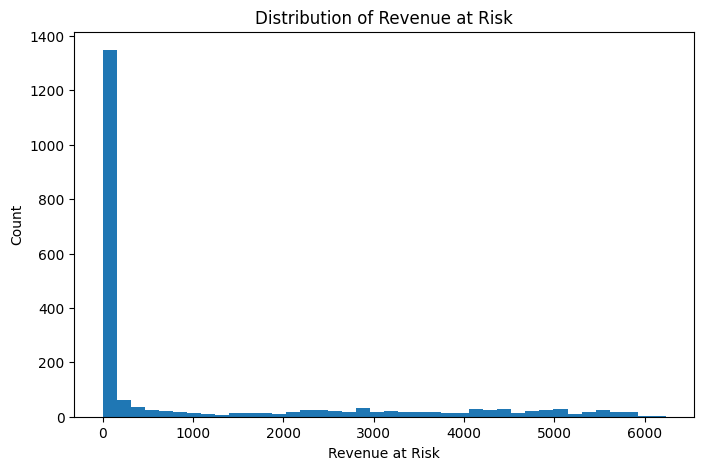

In [262]:
plt.figure(figsize=(8, 5))
plt.hist(test_results['revenue_at_risk'], bins=40)
plt.xlabel('Revenue at Risk')
plt.ylabel('Count')
plt.title('Distribution of Revenue at Risk')
plt.show()

In [263]:
heuristic_df = test_results.sample(n=min(1000, len(test_results)), random_state=42).copy()

CONTACT_CAP = 150
BUDGET = 2500

heuristic_df['high_risk_flag'] = (heuristic_df['p_churn'] >= 0.80).astype(int)

def summarize_strategy(selected_df, strategy_name):
    if selected_df.empty:
        return {
            'strategy': strategy_name,
            'n_selected': 0,
            'total_cost': 0,
            'expected_value': 0,
            'high_risk_coverage': 0,
            'avg_p_churn': 0,
            'avg_cltv': 0
        }

    total_high_risk = max(1, heuristic_df['high_risk_flag'].sum())
    return {
        'strategy': strategy_name,
        'n_selected': len(selected_df),
        'total_cost': selected_df['assigned_cost'].sum(),
        'expected_value': selected_df['assigned_value'].sum(),
        'high_risk_coverage': selected_df['high_risk_flag'].sum() / total_high_risk,
        'avg_p_churn': selected_df['p_churn'].mean(),
        'avg_cltv': selected_df['cltv'].mean()
    }

In [264]:
def strategy_random(df_in, n=150, budget=2500):
    np.random.seed(42)
    temp = df_in.copy().sample(frac=1, random_state=42)
    selected = []
    cost_used = 0

    for _, row in temp.iterrows():
        if len(selected) >= n:
            break

        assigned = None
        for j in [1, 2, 3]:
            if row[f'v{j}'] > 0 and cost_used + tier_params[j]['cost'] <= budget:
                assigned = j
                break

        if assigned is not None:
            row2 = row.copy()
            row2['assigned_tier'] = assigned
            row2['assigned_cost'] = tier_params[assigned]['cost']
            row2['assigned_value'] = row[f'v{assigned}']
            selected.append(row2)
            cost_used += tier_params[assigned]['cost']

    return pd.DataFrame(selected)


def strategy_top_pchurn(df_in, n=150, budget=2500):
    temp = df_in.copy().sort_values('p_churn', ascending=False)
    selected = []
    cost_used = 0

    for _, row in temp.iterrows():
        if len(selected) >= n:
            break

        assigned = None
        for j in [1, 2, 3]:
            if row[f'v{j}'] > 0 and cost_used + tier_params[j]['cost'] <= budget:
                assigned = j
                break

        if assigned is not None:
            row2 = row.copy()
            row2['assigned_tier'] = assigned
            row2['assigned_cost'] = tier_params[assigned]['cost']
            row2['assigned_value'] = row[f'v{assigned}']
            selected.append(row2)
            cost_used += tier_params[assigned]['cost']

    return pd.DataFrame(selected)


def strategy_top_revenue_risk(df_in, n=150, budget=2500):
    temp = df_in.copy().sort_values('revenue_at_risk', ascending=False)
    selected = []
    cost_used = 0

    for _, row in temp.iterrows():
        if len(selected) >= n:
            break

        assigned = None
        for j in [1, 2, 3]:
            if row[f'v{j}'] > 0 and cost_used + tier_params[j]['cost'] <= budget:
                assigned = j
                break

        if assigned is not None:
            row2 = row.copy()
            row2['assigned_tier'] = assigned
            row2['assigned_cost'] = tier_params[assigned]['cost']
            row2['assigned_value'] = row[f'v{assigned}']
            selected.append(row2)
            cost_used += tier_params[assigned]['cost']

    return pd.DataFrame(selected)


def strategy_upward_greedy(df_in, n=150, budget=2500):
    temp = df_in.copy()
    temp = temp[temp['v1'] > 0].copy()
    temp = temp.sort_values('v1', ascending=False).head(n).copy()

    temp['assigned_tier'] = 1
    temp['assigned_cost'] = tier_params[1]['cost']
    temp['assigned_value'] = temp['v1']

    cost_used = temp['assigned_cost'].sum()
    remaining_budget = budget - cost_used

    if remaining_budget < 0:
        max_n = budget // tier_params[1]['cost']
        temp = temp.head(max_n).copy()
        temp['assigned_tier'] = 1
        temp['assigned_cost'] = tier_params[1]['cost']
        temp['assigned_value'] = temp['v1']
        cost_used = temp['assigned_cost'].sum()
        remaining_budget = budget - cost_used

    temp['gain_12'] = temp['v2'] - temp['v1']
    upgrade_12 = temp[temp['gain_12'] > 0].sort_values('gain_12', ascending=False)

    for idx, row in upgrade_12.iterrows():
        extra_cost = tier_params[2]['cost'] - tier_params[1]['cost']
        if remaining_budget >= extra_cost:
            temp.loc[idx, 'assigned_tier'] = 2
            temp.loc[idx, 'assigned_cost'] = tier_params[2]['cost']
            temp.loc[idx, 'assigned_value'] = temp.loc[idx, 'v2']
            remaining_budget -= extra_cost

    temp['current_value'] = np.where(temp['assigned_tier'] == 1, temp['v1'], temp['v2'])
    temp['current_cost'] = np.where(temp['assigned_tier'] == 1, tier_params[1]['cost'], tier_params[2]['cost'])
    temp['gain_to_3'] = temp['v3'] - temp['current_value']

    upgrade_23 = temp[temp['gain_to_3'] > 0].sort_values('gain_to_3', ascending=False)

    for idx, row in upgrade_23.iterrows():
        extra_cost = tier_params[3]['cost'] - temp.loc[idx, 'current_cost']
        if remaining_budget >= extra_cost:
            temp.loc[idx, 'assigned_tier'] = 3
            temp.loc[idx, 'assigned_cost'] = tier_params[3]['cost']
            temp.loc[idx, 'assigned_value'] = temp.loc[idx, 'v3']
            temp.loc[idx, 'current_cost'] = tier_params[3]['cost']
            temp.loc[idx, 'current_value'] = temp.loc[idx, 'v3']
            remaining_budget -= extra_cost

    return temp.copy()


def strategy_best_value_greedy(df_in, n=150, budget=2500):
    temp = df_in.copy().sort_values('best_value', ascending=False)
    selected = []
    cost_used = 0

    for _, row in temp.iterrows():
        if len(selected) >= n:
            break

        best_tier = int(row['best_tier'])
        best_value = row['best_value']
        best_cost = tier_params[best_tier]['cost']

        if best_value > 0 and cost_used + best_cost <= budget:
            row2 = row.copy()
            row2['assigned_tier'] = best_tier
            row2['assigned_cost'] = best_cost
            row2['assigned_value'] = best_value
            selected.append(row2)
            cost_used += best_cost

    return pd.DataFrame(selected)

In [265]:
strategy_outputs['Random'] = strategy_random(heuristic_df, n=CONTACT_CAP, budget=BUDGET)
strategy_outputs['Top_pChurn'] = strategy_top_pchurn(heuristic_df, n=CONTACT_CAP, budget=BUDGET)
strategy_outputs['Top_RevenueAtRisk'] = strategy_top_revenue_risk(heuristic_df, n=CONTACT_CAP, budget=BUDGET)
strategy_outputs['Upward_Greedy'] = strategy_upward_greedy(heuristic_df, n=CONTACT_CAP, budget=BUDGET)
strategy_outputs['Best_Value_Greedy'] = strategy_best_value_greedy(heuristic_df, n=CONTACT_CAP, budget=BUDGET)
strategy_summary = []
for name, out_df in strategy_outputs.items():
    strategy_summary.append(summarize_strategy(out_df, name))

strategy_summary_df = pd.DataFrame(strategy_summary).sort_values('expected_value', ascending=False)
display(strategy_summary_df)

,strategy,n_selected,total_cost,expected_value,high_risk_coverage,avg_p_churn,avg_cltv
3,Upward_Greedy,150,2495,185734.295466,0.653333,0.981487,4895.866667
4,Best_Value_Greedy,50,2500,122734.081429,0.222222,0.996128,5587.840000
2,Top_RevenueAtRisk,150,750,71220.483422,0.653333,0.981487,4895.866667
1,Top_pChurn,150,750,59860.607383,0.666667,0.999099,4044.340000
0,Random,150,750,38078.763026,0.342222,0.599079,4416.353333


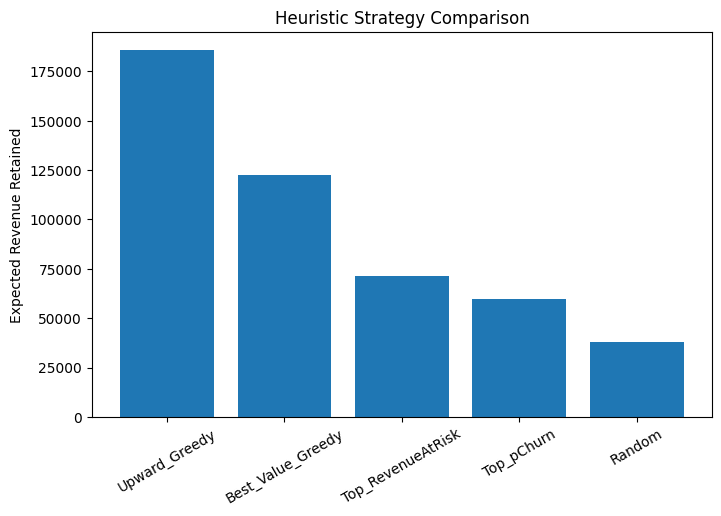

In [266]:
plt.figure(figsize=(8, 5))
plt.bar(strategy_summary_df['strategy'], strategy_summary_df['expected_value'])
plt.xticks(rotation=30)
plt.ylabel('Expected Revenue Retained')
plt.title('Heuristic Strategy Comparison')
plt.show()

In [267]:
cluster_strategy_rows = []
for name, out_df in strategy_outputs.items():
    if len(out_df) == 0:
        continue
    ctab = out_df['cluster_name'].value_counts(normalize=True)
    for c_name, pct in ctab.items():
        cluster_strategy_rows.append({
            'strategy': name,
            'cluster_name': c_name,
            'pct_selected': pct
        })

cluster_strategy_df = pd.DataFrame(cluster_strategy_rows)
display(cluster_strategy_df)

,strategy,cluster_name,pct_selected
0,Random,Early_High_Risk,0.566667
1,Random,Stable_Low_Usage,0.206667
2,Random,High_Value_Bundled,0.166667
3,Random,Loyal_Advocates,0.060000
4,Top_pChurn,Early_High_Risk,0.893333
5,Top_pChurn,High_Value_Bundled,0.073333
6,Top_pChurn,Stable_Low_Usage,0.033333
7,Top_RevenueAtRisk,Early_High_Risk,0.753333
8,Top_RevenueAtRisk,High_Value_Bundled,0.173333
9,Top_RevenueAtRisk,Stable_Low_Usage,0.060000


In [268]:
cluster_perf_rows = []
for c_name, sub in test_results.groupby('cluster_name'):
    idx = sub.index
    if sub['target'].nunique() < 2:
        auc_val = np.nan
    else:
        auc_val = roc_auc_score(sub['target'], test_results.loc[idx, 'p_churn'])
    cluster_perf_rows.append({
        'cluster_name': c_name,
        'n_customers': len(sub),
        'churn_rate': sub['target'].mean(),
        'avg_p_churn': sub['p_churn'].mean(),
        'auc_within_cluster': auc_val,
        'avg_revenue_at_risk': sub['revenue_at_risk'].mean()
    })

cluster_perf_df = pd.DataFrame(cluster_perf_rows)
display(cluster_perf_df)


,cluster_name,n_customers,churn_rate,avg_p_churn,auc_within_cluster,avg_revenue_at_risk
0,Early_High_Risk,644,0.672360,0.665285,0.987369,2623.188564
1,High_Value_Bundled,509,0.157171,0.160300,0.992366,803.728770
2,Loyal_Advocates,352,0.011364,0.018315,1.000000,85.589015
3,Stable_Low_Usage,608,0.072368,0.059613,0.955714,277.234731


In [269]:
X_train_nosat, X_test_nosat = prepare_X(train_df, test_df, features_no_satisfaction)

logit_nosat = LogisticRegression(
    penalty='l2',
    C=best_C,
    solver='liblinear',
    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)

res_nosat, prob_nosat, pred_nosat, fitted_nosat = evaluate_classifier(
    logit_nosat,
    X_train_nosat,
    y_train,
    X_test_nosat,
    y_test,
    model_name='Logistic_NoSatisfaction_NoChurnScore'
)

audit_compare_df = pd.DataFrame([
    clean_audit_results,
    res_leaky_strong,
    res_nosat
])
display(audit_compare_df)


,model,accuracy,precision,recall,f1,auc,lift_top_10pct
0,Logit_Clean_WithCluster,0.946995,0.863857,0.950089,0.904924,0.990435,3.766488
1,Logit_Leaky_Strong,0.945575,0.862013,0.946524,0.902294,0.990714,3.766488
2,Logistic_NoSatisfaction_NoChurnScore,0.854709,0.675900,0.869875,0.760717,0.928259,3.445177


In [270]:
mature_train = model_df[model_df['tenure_months'] <= 36].copy()
mature_test = model_df[model_df['tenure_months'] > 36].copy()

if len(mature_train) > 200 and len(mature_test) > 200 and mature_train['target'].nunique() == 2 and mature_test['target'].nunique() == 2:
    temp_train = mature_train.merge(train_df[['customer_id', 'cluster_name']], on='customer_id', how='left')
    temp_test = mature_test.merge(test_df[['customer_id', 'cluster_name']], on='customer_id', how='left')

    temp_train['cluster_name'] = temp_train['cluster_name'].fillna('Unknown')
    temp_test['cluster_name'] = temp_test['cluster_name'].fillna('Unknown')

    temp_features = [c for c in base_features if c in temp_train.columns] + ['cluster_name']
    X_temp_train, X_temp_test = prepare_X(temp_train, temp_test, temp_features)
    y_temp_train = temp_train['target']
    y_temp_test = temp_test['target']

    temp_model = LogisticRegression(
        penalty='l2', C=best_C, solver='liblinear', random_state=42, max_iter=1000, class_weight='balanced'
    )
    temp_res, temp_prob, temp_pred, _ = evaluate_classifier(
        temp_model, X_temp_train, y_temp_train, X_temp_test, y_temp_test, model_name='TenureSplit_Robustness_Logit'
    )
    display(pd.DataFrame([temp_res]))


,model,accuracy,precision,recall,f1,auc,lift_top_10pct
0,TenureSplit_Robustness_Logit,0.974675,0.960784,0.821229,0.885542,0.989158,8.159143


In [271]:
save_cols = [
    'customer_id',
    'target',
    'cluster_name',
    'cltv',
    'p_churn',
    'revenue_at_risk',
    'v1',
    'v2',
    'v3',
    'best_tier',
    'best_value',
    'high_risk_flag',
    'tenure_months',
    'monthly_charge',
    'service_bundle_count',
    'engagement_index',
    'num_referrals'
]
save_cols = [c for c in save_cols if c in test_results.columns]

enriched_test = test_results[save_cols].copy()
enriched_test.to_csv('update2_enriched_test_for_update3.csv', index=False)
print('Saved: update2_enriched_test_for_update3.csv')


Saved: update2_enriched_test_for_update3.csv


In [272]:
print('\n1. Leakage audit summary')
display(audit_df)

print('\n2. With vs without cluster')
display(comparison_df)

print('\n3. Model comparison')
display(model_comparison_df)

print('\n4. Strategy comparison')
display(strategy_summary_df)

print('\n5. Cluster robustness summary')
display(cluster_perf_df)


1. Leakage audit summary


,model,accuracy,precision,recall,f1,auc,lift_top_10pct
0,Logit_Clean_WithCluster,0.946995,0.863857,0.950089,0.904924,0.990435,3.766488
1,Logit_Leaky_Strong,0.945575,0.862013,0.946524,0.902294,0.990714,3.766488



2. With vs without cluster


,model,accuracy,precision,recall,f1,auc,lift_top_10pct
0,Logistic_NoCluster,0.945102,0.860616,0.946524,0.901528,0.990714,3.766488
1,Logistic_WithCluster,0.946995,0.863857,0.950089,0.904924,0.990435,3.766488



3. Model comparison


,model,accuracy,precision,recall,f1,auc,lift_top_10pct
3,XGBoost,0.960719,0.950943,0.898396,0.923923,0.991451,3.766488
1,Logistic_L2_CV,0.946522,0.863636,0.948307,0.903993,0.990659,3.766488
0,DecisionTree_CV,0.930904,0.818740,0.950089,0.879538,0.984269,3.766488
2,RandomForest,0.946048,0.883362,0.918004,0.900350,0.982635,3.766488



4. Strategy comparison


,strategy,n_selected,total_cost,expected_value,high_risk_coverage,avg_p_churn,avg_cltv
3,Upward_Greedy,150,2495,185734.295466,0.653333,0.981487,4895.866667
4,Best_Value_Greedy,50,2500,122734.081429,0.222222,0.996128,5587.840000
2,Top_RevenueAtRisk,150,750,71220.483422,0.653333,0.981487,4895.866667
1,Top_pChurn,150,750,59860.607383,0.666667,0.999099,4044.340000
0,Random,150,750,38078.763026,0.342222,0.599079,4416.353333



5. Cluster robustness summary


,cluster_name,n_customers,churn_rate,avg_p_churn,auc_within_cluster,avg_revenue_at_risk
0,Early_High_Risk,644,0.672360,0.665285,0.987369,2623.188564
1,High_Value_Bundled,509,0.157171,0.160300,0.992366,803.728770
2,Loyal_Advocates,352,0.011364,0.018315,1.000000,85.589015
3,Stable_Low_Usage,608,0.072368,0.059613,0.955714,277.234731
